# TP 7 : La Fuite de Données (Data Leakage)
(CORRECTION DÉTAILLÉE)

**Dataset :** Diabetes 130-US Hospitals (UCI ML Repository)  
**Contexte :** 101 766 hospitalisations dans 130 hôpitaux américains (1999-2008).  
**Tâche :** Prédire si un patient diabétique sera réadmis dans les 30 jours suivant sa sortie.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

np.random.seed(42)
pd.set_option('display.max_columns', 20)

---
## Chargement et Préparation des Données

In [2]:
print("Chargement du dataset diabetes-130...")
dataset = fetch_ucirepo(id=296)
# patient_nbr et encounter_id sont dans dataset.data.ids (pas dans features)
df_raw = pd.concat([dataset.data.ids, dataset.data.features, dataset.data.targets], axis=1)
print(f"Dimensions : {df_raw.shape}")

Chargement du dataset diabetes-130...
Dimensions : (101766, 50)


/opt/miniconda3/envs/cours/lib/python3.11/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [3]:
df = df_raw.copy()
df['readmit_30'] = (df['readmitted'] == '<30').astype(int)
df.replace('?', np.nan, inplace=True)

FEATS_NUM = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

df_num = df[FEATS_NUM + ['readmit_30', 'patient_nbr']].dropna().copy()

print(f"Dataset de travail : {len(df_num)} lignes")
print(f"Taux de réadmission <30j : {df_num['readmit_30'].mean():.2%}")
print(f"Patients uniques : {df_num['patient_nbr'].nunique()}")

Dataset de travail : 101766 lignes
Taux de réadmission <30j : 11.16%
Patients uniques : 71518


---
## Scénario 1 : Fuite de Prétraitement

In [4]:
X = df_num[FEATS_NUM].values
y = df_num['readmit_30'].values

# ❌ Normalisation AVANT le split
scaler_bad = StandardScaler()
X_scaled_all = scaler_bad.fit_transform(X)

X_train_bad, X_test_bad, y_train, y_test = train_test_split(
    X_scaled_all, y, test_size=0.2, random_state=42, stratify=y
)
model_bad = LogisticRegression(max_iter=500, class_weight='balanced')
model_bad.fit(X_train_bad, y_train)
f1_bad = f1_score(y_test, model_bad.predict(X_test_bad))
print(f"F1 (AVEC fuite de prétraitement) : {f1_bad:.4f}")

F1 (AVEC fuite de prétraitement) : 0.2526


In [5]:
# ✅ Split AVANT normalisation
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler_good = StandardScaler()
X_train_good = scaler_good.fit_transform(X_train_raw)  # fit + transform
X_test_good  = scaler_good.transform(X_test_raw)        # transform seulement

model_good = LogisticRegression(max_iter=500, class_weight='balanced')
model_good.fit(X_train_good, y_train)
f1_good = f1_score(y_test, model_good.predict(X_test_good))
print(f"F1 (SANS fuite, split d'abord) : {f1_good:.4f}")

print("\n💡 Explication :")
print("   Le scaler 'avec fuite' connaît la moyenne et l'écart-type des données de test.")
print("   Sur ce dataset, la différence est faible mais peut être significative sur des datasets plus petits.")
print("   En production, ces statistiques ne sont pas disponibles pour les futurs patients.")

F1 (SANS fuite, split d'abord) : 0.2524

💡 Explication :
   Le scaler 'avec fuite' connaît la moyenne et l'écart-type des données de test.
   Sur ce dataset, la différence est faible mais peut être significative sur des datasets plus petits.
   En production, ces statistiques ne sont pas disponibles pour les futurs patients.


F1 (Pipeline cross-val 5 folds) : 0.2481 +/- 0.0059


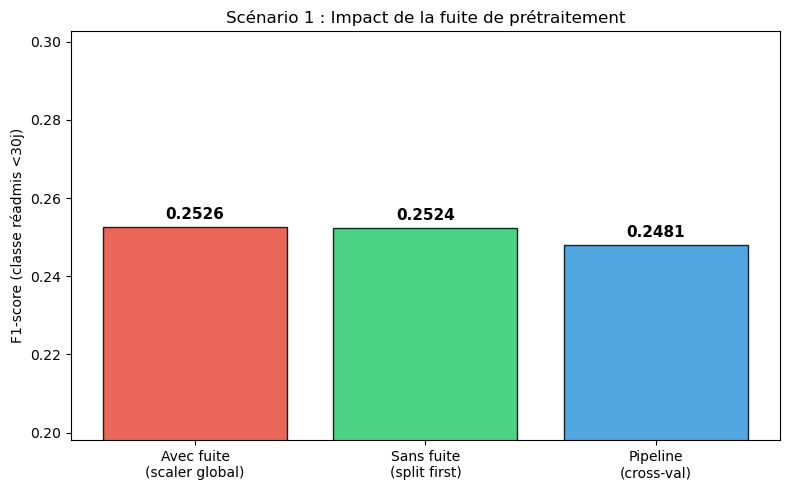

In [6]:
# ✅ Solution la plus propre : Pipeline + cross-validation
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=500, class_weight='balanced'))
])

# cross_val_score refait le fit du scaler sur chaque fold de train automatiquement
scores_pipe = cross_val_score(pipe, X, y, cv=5, scoring='f1', n_jobs=-1)
f1_pipe = scores_pipe.mean()
print(f"F1 (Pipeline cross-val 5 folds) : {f1_pipe:.4f} +/- {scores_pipe.std():.4f}")

# Visualisation comparative
labels = ['Avec fuite\n(scaler global)', 'Sans fuite\n(split first)', 'Pipeline\n(cross-val)']
vals   = [f1_bad, f1_good, f1_pipe]
colors = ['#e74c3c', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='black')
ax.set_ylim(max(0, min(vals) - 0.05), min(1, max(vals) + 0.05))
ax.set_ylabel('F1-score (classe réadmis <30j)')
ax.set_title('Scénario 1 : Impact de la fuite de prétraitement')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Scénario 2 : Fuite d'Encodage Cible (Target Encoding Leakage)

Taux de réadmission par tranche d'âge :
          taux_readmission  n_patients
age                                   
[0-10)              0.0186         161
[10-20)             0.0579         691
[20-30)             0.1424        1657
[30-40)             0.1123        3775
[40-50)             0.1060        9685
[50-60)             0.0967       17256
[60-70)             0.1113       22483
[70-80)             0.1177       26068
[80-90)             0.1208       17197
[90-100)            0.1110        2793


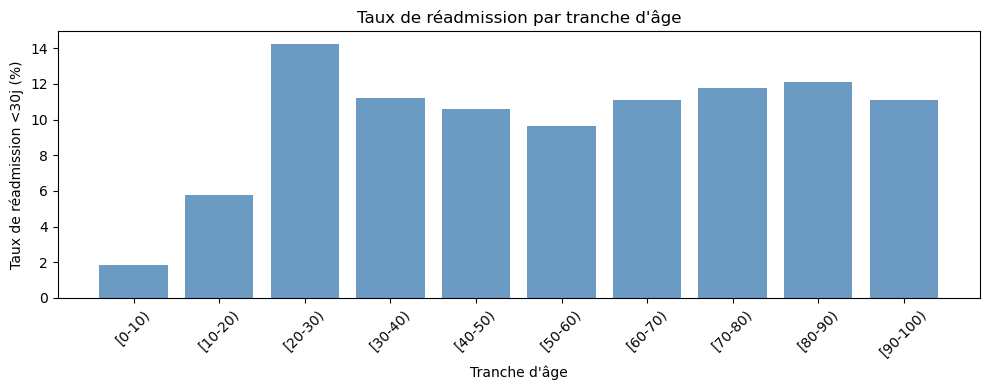

In [7]:
df_age = df[['age', 'readmit_30']].dropna().copy()

taux_par_age = df_age.groupby('age')['readmit_30'].agg(['mean', 'count'])
taux_par_age.columns = ['taux_readmission', 'n_patients']
taux_par_age = taux_par_age.sort_index()

print("Taux de réadmission par tranche d'âge :")
print(taux_par_age.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(taux_par_age.index, taux_par_age['taux_readmission'] * 100,
       color='steelblue', alpha=0.8)
ax.set_xlabel("Tranche d'âge")
ax.set_ylabel("Taux de réadmission <30j (%)")
ax.set_title("Taux de réadmission par tranche d'âge")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
df_s2 = df[FEATS_NUM + ['age', 'readmit_30']].dropna().copy()

# ❌ Encoding calculé sur tout le dataset
encoding_global = df_s2.groupby('age')['readmit_30'].mean()
df_s2['age_encoded'] = df_s2['age'].map(encoding_global)

X_leak = df_s2[FEATS_NUM + ['age_encoded']].values
y_s2   = df_s2['readmit_30'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_leak, y_s2, test_size=0.2, random_state=42, stratify=y_s2)
m = LogisticRegression(max_iter=500, class_weight='balanced')
m.fit(X_tr, y_tr)
f1_enc_leak = f1_score(y_te, m.predict(X_te))
print(f"F1 target encoding AVEC fuite : {f1_enc_leak:.4f}")

F1 target encoding AVEC fuite : 0.2535


In [9]:
# ✅ Encoding calculé uniquement sur le train
idx = np.arange(len(df_s2))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42, stratify=y_s2)

df_train_s2 = df_s2.iloc[idx_train].copy()
df_test_s2  = df_s2.iloc[idx_test].copy()

# Encodage calculé UNIQUEMENT sur le train
encoding_train = df_train_s2.groupby('age')['readmit_30'].mean()
global_mean = df_train_s2['readmit_30'].mean()  # fallback pour catégories inconnues

df_train_s2['age_enc'] = df_train_s2['age'].map(encoding_train)
df_test_s2['age_enc']  = df_test_s2['age'].map(encoding_train).fillna(global_mean)

feats_ok = FEATS_NUM + ['age_enc']
X_tr_ok = df_train_s2[feats_ok].values
X_te_ok = df_test_s2[feats_ok].values
y_tr_ok = df_train_s2['readmit_30'].values
y_te_ok = df_test_s2['readmit_30'].values

m_ok = LogisticRegression(max_iter=500, class_weight='balanced')
m_ok.fit(X_tr_ok, y_tr_ok)
f1_enc_ok = f1_score(y_te_ok, m_ok.predict(X_te_ok))
print(f"F1 target encoding SANS fuite : {f1_enc_ok:.4f}")

print("\n💡 Explication :")
print(f"   Différence : {f1_enc_leak - f1_enc_ok:+.4f}")
print("   Le target encoding 'avec fuite' connaît la réponse moyenne des patients du test.")
print("   Sur un petit dataset, cet effet est amplifié.")

F1 target encoding SANS fuite : 0.2545

💡 Explication :
   Différence : -0.0010
   Le target encoding 'avec fuite' connaît la réponse moyenne des patients du test.
   Sur un petit dataset, cet effet est amplifié.


---
## Scénario 3 : Fuite Patient (Group Leakage)

Distribution du nombre de séjours par patient :
1     54745
2     10434
3      3328
4      1421
5       717
6       346
7       207
8       111
9        70
10       42
Name: count, dtype: int64

Patients avec ≥ 2 séjours : 16773 (23.5% des patients)


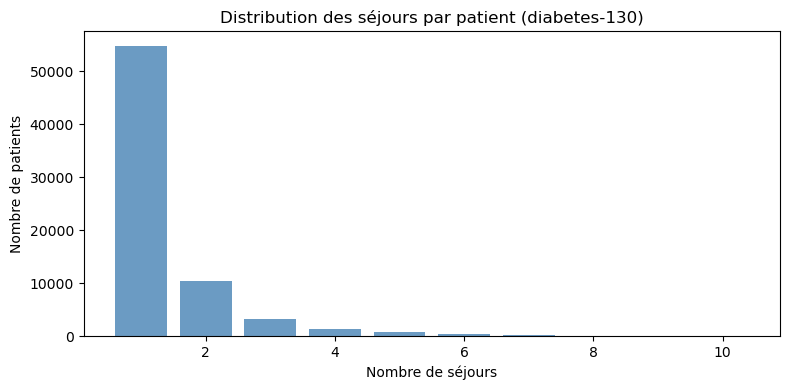


Avec split ALÉATOIRE :
  Patients dans train : 60109
  Patients dans test  : 18416
  Patients dans LES DEUX : 7007 (38.0% du test) ← FUITE !


In [10]:
sejours_par_patient = df_num.groupby('patient_nbr').size()

print("Distribution du nombre de séjours par patient :")
print(sejours_par_patient.value_counts().sort_index().head(10))
print(f"\nPatients avec ≥ 2 séjours : {(sejours_par_patient >= 2).sum()} "
      f"({(sejours_par_patient >= 2).mean():.1%} des patients)")

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
vc = sejours_par_patient.value_counts().sort_index()
ax.bar(vc.index[:10], vc.values[:10], color='steelblue', alpha=0.8)
ax.set_xlabel("Nombre de séjours")
ax.set_ylabel("Nombre de patients")
ax.set_title("Distribution des séjours par patient (diabetes-130)")
plt.tight_layout()
plt.show()

# Quantifier la fuite avec un split aléatoire
idx_all = df_num.index.values
idx_train_rand, idx_test_rand = train_test_split(idx_all, test_size=0.2, random_state=42)

patients_train = set(df_num.loc[idx_train_rand, 'patient_nbr'])
patients_test  = set(df_num.loc[idx_test_rand,  'patient_nbr'])
overlap = patients_train & patients_test

print(f"\nAvec split ALÉATOIRE :")
print(f"  Patients dans train : {len(patients_train)}")
print(f"  Patients dans test  : {len(patients_test)}")
print(f"  Patients dans LES DEUX : {len(overlap)} ({len(overlap)/len(patients_test):.1%} du test) ← FUITE !")

In [11]:
X_s3 = df_num[FEATS_NUM].values
y_s3 = df_num['readmit_30'].values
groups = df_num['patient_nbr'].values

# ❌ Split aléatoire
mask_train = np.isin(df_num.index, idx_train_rand)
mask_test  = np.isin(df_num.index, idx_test_rand)

model_rand = LogisticRegression(max_iter=500, class_weight='balanced')
model_rand.fit(X_s3[mask_train], y_s3[mask_train])
f1_rand = f1_score(y_s3[mask_test], model_rand.predict(X_s3[mask_test]))
print(f"F1 (split aléatoire, AVEC fuite patient) : {f1_rand:.4f}")

# ✅ GroupShuffleSplit : aucun patient dans les deux sets
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_s3, y_s3, groups=groups))

# Vérification
overlap_grp = set(groups[train_idx]) & set(groups[test_idx])
print(f"\nAvec GroupShuffleSplit :")
print(f"  Patients dans les deux sets : {len(overlap_grp)} ← Doit être 0 ✓")

model_grp = LogisticRegression(max_iter=500, class_weight='balanced')
model_grp.fit(X_s3[train_idx], y_s3[train_idx])
f1_grp = f1_score(y_s3[test_idx], model_grp.predict(X_s3[test_idx]))
print(f"F1 (GroupShuffleSplit, SANS fuite patient) : {f1_grp:.4f}")

print("\n💡 Explication :")
print(f"   Le split aléatoire donne un F1 gonflé de {f1_rand - f1_grp:+.4f} points.")
print("   Le modèle 'apprend' des patterns propres à chaque patient (comorbidités, traitements)")
print("   qui ne se généralisent pas à de nouveaux patients.")

F1 (split aléatoire, AVEC fuite patient) : 0.2484

Avec GroupShuffleSplit :
  Patients dans les deux sets : 0 ← Doit être 0 ✓
F1 (GroupShuffleSplit, SANS fuite patient) : 0.2394

💡 Explication :
   Le split aléatoire donne un F1 gonflé de +0.0090 points.
   Le modèle 'apprend' des patterns propres à chaque patient (comorbidités, traitements)
   qui ne se généralisent pas à de nouveaux patients.


---
## Synthèse : Les 3 fuites côte à côte

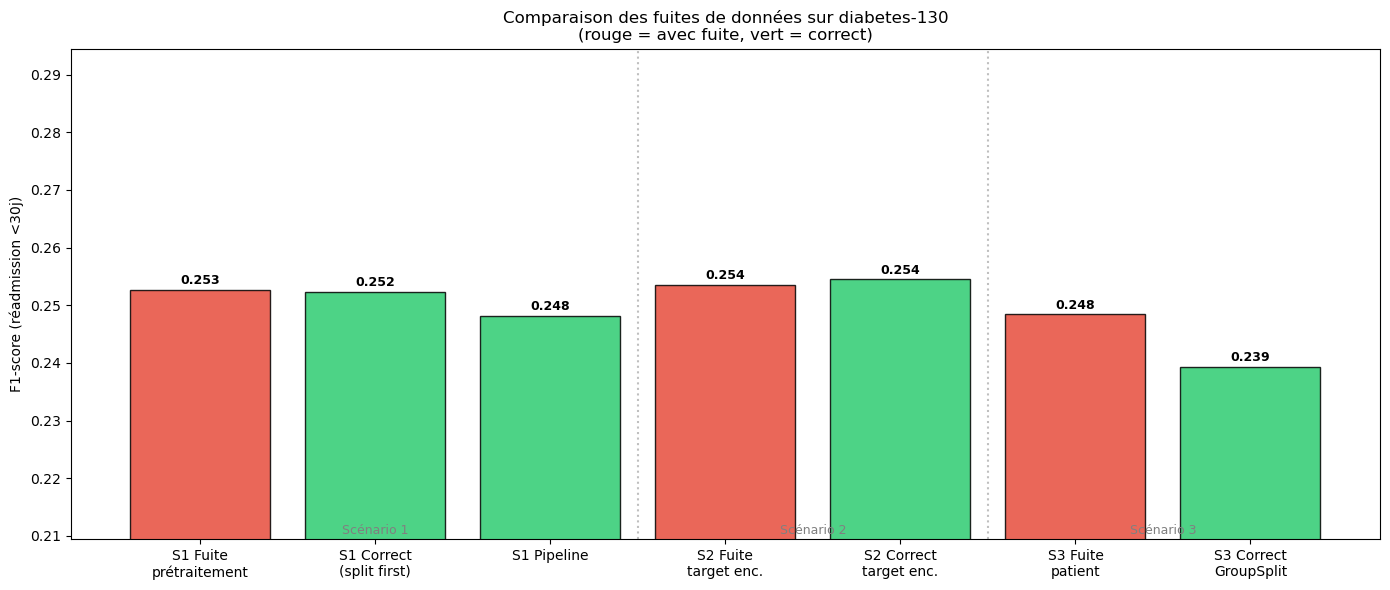


📋 Récapitulatif des fuites détectées sur diabetes-130 :
  Prétraitement       : +0.0003 points de F1 (fuite vs correct)
  Target encoding     : -0.0010 points de F1 (fuite vs correct)
  Patient/groupe      : +0.0090 points de F1 (fuite vs correct)


In [12]:
resultats = {
    'S1 Fuite\nprétraitement': f1_bad,
    'S1 Correct\n(split first)': f1_good,
    'S1 Pipeline': f1_pipe,
    'S2 Fuite\ntarget enc.': f1_enc_leak,
    'S2 Correct\ntarget enc.': f1_enc_ok,
    'S3 Fuite\npatient': f1_rand,
    'S3 Correct\nGroupSplit': f1_grp,
}

colors = ['#e74c3c', '#2ecc71', '#2ecc71',
          '#e74c3c', '#2ecc71',
          '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(resultats.keys(), resultats.values(), color=colors, alpha=0.85, edgecolor='black')
ax.set_ylim(max(0, min(resultats.values()) - 0.03), min(1, max(resultats.values()) + 0.04))
ax.set_ylabel('F1-score (réadmission <30j)')
ax.set_title('Comparaison des fuites de données sur diabetes-130\n(rouge = avec fuite, vert = correct)')
for bar, v in zip(bars, resultats.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# Séparateurs visuels entre scénarios
ax.axvline(x=2.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=4.5, color='gray', linestyle=':', alpha=0.5)
ax.text(1, ax.get_ylim()[0] + 0.001, 'Scénario 1', ha='center', color='gray', fontsize=9)
ax.text(3.5, ax.get_ylim()[0] + 0.001, 'Scénario 2', ha='center', color='gray', fontsize=9)
ax.text(5.5, ax.get_ylim()[0] + 0.001, 'Scénario 3', ha='center', color='gray', fontsize=9)
plt.tight_layout()
plt.show()

print("\n📋 Récapitulatif des fuites détectées sur diabetes-130 :")
for label, (k_leak, k_ok) in [
    ('Prétraitement', ('S1 Fuite\nprétraitement', 'S1 Correct\n(split first)')),
    ('Target encoding', ('S2 Fuite\ntarget enc.', 'S2 Correct\ntarget enc.')),
    ('Patient/groupe', ('S3 Fuite\npatient', 'S3 Correct\nGroupSplit'))
]:
    delta = resultats[k_leak] - resultats[k_ok]
    print(f"  {label:<20}: {delta:+.4f} points de F1 (fuite vs correct)")

---
## Réponses aux Questions de Réflexion

**1. Pourquoi le Pipeline protège-t-il en cross-validation ?**  
Avec Pipeline, sklearn exécute `fit_transform` sur le fold de train et `transform` sur le fold de validation à chaque itération. Sans Pipeline, si on normalise avant la cross-val, les folds de validation ont influencé les paramètres du scaler → fuite à chaque fold.

**2. Autres fuites dans ce dataset ?**  
- `discharge_disposition_id = 20` (patient décédé pendant le séjour) → ces patients ne peuvent jamais être réadmis → la colonne encode partiellement la cible `readmitted=No`
- `number_inpatient` et `number_emergency` dans l'année précédente sont légitimes (données passées), mais si calculés sur la même période → fuite
- `payer_code` et `medical_specialty` pourraient être renseignés après le diagnostic → fuite potentielle selon le moment de collecte

**3. GroupShuffleSplit vs train_test_split ?**  
GroupShuffleSplit donne une estimation plus **pessimiste** (vraiment sur des nouveaux patients) mais aussi plus **réaliste** de la performance en production. La variance est plus haute car la taille effective du test dépend de la distribution des groupes.